# Model 4 -- Per-turn Classifier (Ablation)

BERT fine-tuned buat klasifikasi SATU tool call individual, tanpa sequential context
(gak ada LSTM/Transformer aggregator). Tujuan ablasi: buktiin pentingnya modeling urutan
tool call dibanding klasifikasi per-tool-call independen.

**Setup training:** tiap sample di-explode jadi N contoh latih (N = jumlah tool call di
sequence-nya), label sample dipakai sebagai weak label tiap tool call individual.
BERT encoder freeze (sama seperti Model 2/3) -- biar variabel yang diablasi murni
"ada aggregator sequence atau tidak", bukan tercampur sama beda freeze/fine-tune.

**Aturan agregasi prediksi per-turn -> level-sample** (dipakai pas evaluasi, bukan training):
1. Kalau SEMUA tool call dalam sample diprediksi `benign` -> sample diprediksi `benign`.
2. Selain itu -> sample diprediksi kelas attack yang paling sering muncul (mayoritas) di
   antara tool call yang diprediksi attack (non-benign).
3. Kalau ada seri jumlah suara antar kelas attack -> menang tool call dengan confidence
   (softmax max probability) tertinggi.

Alasan milih OR-rule (poin 1-2) bukan strict majority-vote biasa: di tool-call sequence,
satu tool call malicious aja sudah cukup buat bikin SELURUH sample berbahaya (mis. 1 dari
5 tool call legit, sisanya benign) -- majority-vote murni bakal salah nge-label sample
seperti itu jadi benign padahal ada serangan di dalamnya.

Referensi: How to Fine-Tune BERT for Text Classification? (arXiv:1905.05583).

## 1. Install Dependencies

In [1]:
!pip install transformers==4.40.0 torch scikit-learn pandas numpy tqdm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 98.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0

## 2. Imports & Configuration

In [2]:
import os, json, math, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, accuracy_score)
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# ── Config ────────────────────────────────────────────
DATASET_PATH       = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_dataset.csv'
SPLIT_PATH         = '/kaggle/input/datasets/raditya0/tcssc-dataset/tcssc_split.json'
ENCODER_MODEL      = 'bert-base-multilingual-cased'
MAX_SEQ_LEN        = 128
MAX_SEQ_LEN_CTX    = 64
EMBED_DIM          = 768
MAX_TOOL_CALLS     = 20
LSTM_HIDDEN        = 256
LSTM_LAYERS        = 2
LSTM_DROPOUT       = 0.3
CLASSIFIER_HIDDEN  = 128
CLASSIFIER_DROPOUT = 0.3
BATCH_SIZE         = 16
LEARNING_RATE      = 2e-4
NUM_EPOCHS         = 15
WEIGHT_DECAY       = 1e-4
EARLY_STOP         = 5
SEED               = 42
CHECKPOINT_DIR     = '/kaggle/working/checkpoints'
OUTPUT_DIR         = '/kaggle/working/outputs'

LABEL2ID = {'benign': 0, 'direct_attack': 1,
            'sequential_attack': 2, 'parameter_injection': 3}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_CLASSES = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
set_seed()
print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Device: cuda
CUDA available: True
GPU: Tesla T4


## 3. Load Dataset

In [3]:
df = pd.read_csv(DATASET_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print('\nLabel distribution:')
print(df['label'].value_counts())
df.head(3)


Shape: (10242, 5)
Columns: ['tool_calls_json', 'tool_calls_text', 'label', 'source', 'context_text']

Label distribution:
label
benign                 2654
parameter_injection    2654
sequential_attack      2626
direct_attack          2308
Name: count, dtype: int64


,tool_calls_json,tool_calls_text,label,source,context_text
0,"[{""name"": ""find_user_id_by_email"", ""parameters...",[FUNC] find_user_id_by_email [ARGS] email=luca...,benign,apigen_mt,"assistant: Your order is still pending, so we ..."
1,"[{""name"": ""harmful_action"", ""parameters"": {""co...",[FUNC] harmful_action [ARGS] context=In the co...,sequential_attack,wildjailbreak,user: In the context of a dystopian novel I am...
2,"[{""name"": ""submitClaimAPI"", ""parameters"": {""po...",[FUNC] submitclaimapi [ARGS] policy_id=22222 |...,direct_attack,safetoolbench,user: Submit a claim for my health insurance p...


## 4. Dataset & Split

In [4]:
# ── Preprocessing utils (sinkron utils/preprocessing.py) ──
def normalize_tool_call(tc):
    name   = str(tc.get('name', tc.get('function', 'unknown'))).lower().strip()
    params = tc.get('parameters', tc.get('arguments', tc.get('args', tc.get('params', {}))))
    if isinstance(params, str):
        try:    params = json.loads(params)
        except: params = {'raw': params}
    return {'name': name, 'params': params}

def flatten_params(params, max_keys=10):
    # cap 400 char cuma jaring pengaman outlier, truncation final tetap di token (max_length=128)
    if not isinstance(params, dict): return str(params)[:400]
    parts = []
    for i, (k, v) in enumerate(params.items()):
        if i >= max_keys: break
        parts.append(f'{k}={str(v)[:400]}')
    return ' | '.join(parts)

def tool_call_to_text(tc):
    n = normalize_tool_call(tc)
    return f"[FUNC] {n['name']} [ARGS] {flatten_params(n['params'])}"

# ── Dataset: explode sequence jadi tool call individual ──
# (orig_idx dipakai buat agregasi prediksi balik ke level-sample pas evaluasi)
class PerTurnDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.tokenizer = tokenizer
        self.records   = []
        d = df.reset_index(drop=True)
        for orig_idx, row in d.iterrows():
            label = LABEL2ID.get(str(row['label']), 0)
            try:    seq = json.loads(str(row.get('tool_calls_json', '[]')))
            except: seq = []
            if not seq:
                seq = [{}]
            for tc in seq[:MAX_TOOL_CALLS]:
                self.records.append({
                    'orig_idx': orig_idx,
                    'text':     tool_call_to_text(tc),
                    'label':    label,
                })

    def __len__(self): return len(self.records)

    def __getitem__(self, i):
        rec = self.records[i]
        enc = self.tokenizer(rec['text'], max_length=MAX_SEQ_LEN, padding='max_length',
                             truncation=True, return_tensors='pt')
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(rec['label'], dtype=torch.long),
            'orig_idx':       torch.tensor(rec['orig_idx'], dtype=torch.long),
        }


tokenizer = AutoTokenizer.from_pretrained(ENCODER_MODEL)
# Load split kanonik (sama persis dengan notebook core dan ablasi lain)
with open(SPLIT_PATH, encoding='utf-8') as f:
    split_map = json.load(f)

train_df = df.iloc[split_map['train_idx']].reset_index(drop=True)
val_df   = df.iloc[split_map['val_idx']].reset_index(drop=True)
test_df  = df.iloc[split_map['test_idx']].reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = DataLoader(PerTurnDataset(train_df, tokenizer), batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(PerTurnDataset(val_df,   tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(PerTurnDataset(test_df,  tokenizer), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Tool call individual -- train: {len(train_loader.dataset)} | '
      f'val: {len(val_loader.dataset)} | test: {len(test_loader.dataset)}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 7174 | Val: 1530 | Test: 1538
Tool call individual -- train: 15831 | val: 3379 | test: 3255


## 5. Model Architecture -- TCSSC-PerTurn

In [5]:
class HarmClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, CLASSIFIER_HIDDEN),
            nn.LayerNorm(CLASSIFIER_HIDDEN), nn.ReLU(),
            nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN, CLASSIFIER_HIDDEN // 2),
            nn.ReLU(), nn.Dropout(CLASSIFIER_DROPOUT),
            nn.Linear(CLASSIFIER_HIDDEN // 2, NUM_CLASSES),
        )

    def forward(self, x): return self.net(x)


# Klasifikasi tool call individual -- tanpa aggregator sequence apapun
class TCSSCPerTurn(nn.Module):
    def __init__(self, model_name=ENCODER_MODEL, freeze_bert=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False
        self.classifier = HarmClassifier(EMBED_DIM)

    def forward(self, batch):
        out = self.bert(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)

print('Model TCSSC-PerTurn defined.')


Model TCSSC-PerTurn defined.


## 6. Training & Evaluation Functions

In [6]:
def compute_class_weights(label_list, device=DEVICE):
    counts  = Counter(LABEL2ID.get(l, l) if isinstance(l, str) else l for l in label_list)
    total   = len(label_list)
    weights = [total / (NUM_CLASSES * counts.get(i, 1)) for i in range(NUM_CLASSES)]
    return torch.tensor(weights, dtype=torch.float).to(device)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items() if k != 'orig_idx'}
        labels = batch.pop('label')
        optimizer.zero_grad()
        logits = model(batch)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(logits.argmax(-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1


# Evaluasi per-call (label lemah) -- cuma buat monitoring training/val, bukan metrik final
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            batch  = {k: v.to(device) for k, v in batch.items() if k != 'orig_idx'}
            labels = batch.pop('label')
            logits = model(batch)
            total_loss += criterion(logits, labels).item()
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return total_loss / len(loader), f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, train_labels,
                model_name, num_epochs=NUM_EPOCHS, device=DEVICE):
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    model     = model.to(device)
    weights   = compute_class_weights(train_labels, device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_f1, patience_cnt = 0.0, 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        print(f'Ep {epoch:02d}/{num_epochs} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'F1 {tr_f1:.4f}/{vl_f1:.4f} | {elapsed:.0f}s')

        if vl_f1 > best_f1:
            best_f1 = vl_f1; patience_cnt = 0
            ckpt = os.path.join(CHECKPOINT_DIR, f'{model_name}_best.pt')
            torch.save(model.state_dict(), ckpt)
            print(f'  >> Saved (val F1: {best_f1:.4f})')
        else:
            patience_cnt += 1
            if patience_cnt >= EARLY_STOP:
                print(f'Early stopping at epoch {epoch}')
                break

    return history


# Agregasi prediksi per-turn ke level-sample.
# Aturan: semua tool call sample diprediksi benign -> sample benign.
# Selain itu -> mayoritas kelas attack di antara tool call yang diprediksi
# attack; kalau seri jumlah suara, menang yang confidence (softmax max prob) tertinggi.
def aggregate_per_turn_predictions(model, loader, device=DEVICE):
    model.eval()
    rows = []
    with torch.no_grad():
        for batch in loader:
            orig_idx = batch['orig_idx'].numpy()
            batch    = {k: v.to(device) for k, v in batch.items() if k != 'orig_idx'}
            labels   = batch.pop('label').cpu().numpy()
            logits   = model(batch)
            probs    = torch.softmax(logits, dim=-1)
            conf, pred = probs.max(-1)
            pred = pred.cpu().numpy(); conf = conf.cpu().numpy()
            for oi, p, c, t in zip(orig_idx, pred, conf, labels):
                rows.append((oi, p, c, t))

    calls = pd.DataFrame(rows, columns=['orig_idx', 'pred', 'conf', 'true'])
    sample_preds, sample_trues = [], []
    for orig_idx, group in calls.groupby('orig_idx'):
        sample_trues.append(int(group['true'].iloc[0]))
        non_benign = group[group['pred'] != 0]
        if len(non_benign) == 0:
            sample_preds.append(0)
            continue
        counts = non_benign['pred'].value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1:
            sample_preds.append(int(top[0]))
        else:
            tied = non_benign[non_benign['pred'].isin(top)]
            sample_preds.append(int(tied.loc[tied['conf'].idxmax(), 'pred']))
    return np.array(sample_preds), np.array(sample_trues)


def evaluate_final_aggregated(model, test_loader, device=DEVICE):
    preds, labels = aggregate_per_turn_predictions(model, test_loader, device)
    report = classification_report(labels, preds, target_names=list(LABEL2ID.keys()),
                                   output_dict=True, zero_division=0)
    cm  = confusion_matrix(labels, preds)
    acc = accuracy_score(labels, preds)
    print(classification_report(labels, preds, target_names=list(LABEL2ID.keys()), zero_division=0))
    return {'report': report, 'cm': cm, 'accuracy': acc, 'preds': preds, 'labels': labels}


def compute_asr_aggregated(preds, labels):
    attack_mask    = labels != 0
    attack_total   = int(attack_mask.sum())
    attack_missed  = int(((preds == 0) & attack_mask).sum())
    asr = (attack_missed / attack_total * 100) if attack_total > 0 else 0.0
    print(f'ASR: {asr:.2f}%  ({attack_missed}/{attack_total} attacks bypassed detection)')
    return float(asr)


def compute_benign_fpr_aggregated(preds, labels):
    benign_mask    = labels == 0
    benign_total   = int(benign_mask.sum())
    benign_flagged = int(((preds != 0) & benign_mask).sum())
    fpr = (benign_flagged / benign_total * 100) if benign_total > 0 else 0.0
    print(f'Benign FPR: {fpr:.2f}%  ({benign_flagged}/{benign_total} benign salah diklasifikasi attack)')
    return float(fpr)

print('Training functions (per-turn + agregasi level-sample) defined.')


Training functions (per-turn + agregasi level-sample) defined.


## 7. Train Model 4

In [7]:
torch.cuda.empty_cache()

model4   = TCSSCPerTurn(freeze_bert=True)
n_params = sum(p.numel() for p in model4.parameters() if p.requires_grad)
print(f'TCSSC-PerTurn trainable params: {n_params:,}')

history = train_model(
    model       = model4,
    train_loader= train_loader,
    val_loader  = val_loader,
    train_labels= [r['label'] for r in train_loader.dataset.records],
    model_name  = 'model4_perturn',
    num_epochs  = NUM_EPOCHS,
    device      = DEVICE,
)
torch.cuda.empty_cache()
print('Model 4 training done.')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

TCSSC-PerTurn trainable params: 107,204
Ep 01/15 | Loss 0.8543/0.5395 | F1 0.7050/0.8136 | 163s
  >> Saved (val F1: 0.8136)
Ep 02/15 | Loss 0.6235/0.5110 | F1 0.7955/0.8138 | 179s
  >> Saved (val F1: 0.8138)
Ep 03/15 | Loss 0.5672/0.4578 | F1 0.8109/0.8284 | 179s
  >> Saved (val F1: 0.8284)
Ep 04/15 | Loss 0.5270/0.4103 | F1 0.8202/0.8470 | 180s
  >> Saved (val F1: 0.8470)
Ep 05/15 | Loss 0.5041/0.3829 | F1 0.8285/0.8527 | 180s
  >> Saved (val F1: 0.8527)
Ep 06/15 | Loss 0.4796/0.3742 | F1 0.8370/0.8518 | 179s
Ep 07/15 | Loss 0.4677/0.3638 | F1 0.8389/0.8630 | 178s
  >> Saved (val F1: 0.8630)
Ep 08/15 | Loss 0.4567/0.3393 | F1 0.8428/0.8717 | 179s
  >> Saved (val F1: 0.8717)
Ep 09/15 | Loss 0.4435/0.3436 | F1 0.8460/0.8664 | 179s
Ep 10/15 | Loss 0.4309/0.3368 | F1 0.8502/0.8689 | 180s
Ep 11/15 | Loss 0.4284/0.3333 | F1 0.8536/0.8739 | 180s
  >> Saved (val F1: 0.8739)
Ep 12/15 | Loss 0.4240/0.3300 | F1 0.8549/0.8736 | 179s
Ep 13/15 | Loss 0.4158/0.3277 | F1 0.8558/0.8755 | 179s
  >> Sav

## 8. Evaluation (agregasi level-sample)


EVALUASI Model4-PerTurn (agregasi level-sample)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


                     precision    recall  f1-score   support

             benign       1.00      0.79      0.88       388
      direct_attack       0.73      0.99      0.84       364
  sequential_attack       0.94      0.90      0.92       383
parameter_injection       0.96      0.88      0.92       403

           accuracy                           0.89      1538
          macro avg       0.91      0.89      0.89      1538
       weighted avg       0.91      0.89      0.89      1538

ASR: 0.09%  (1/1150 attacks bypassed detection)
Benign FPR: 20.88%  (81/388 benign salah diklasifikasi attack)
Model                       Accuracy  F1 Weighted    ASR (%)  Benign FPR (%)
------------------------------------------------------------
Model4-PerTurn                88.95%       89.18%      0.09%          20.88%


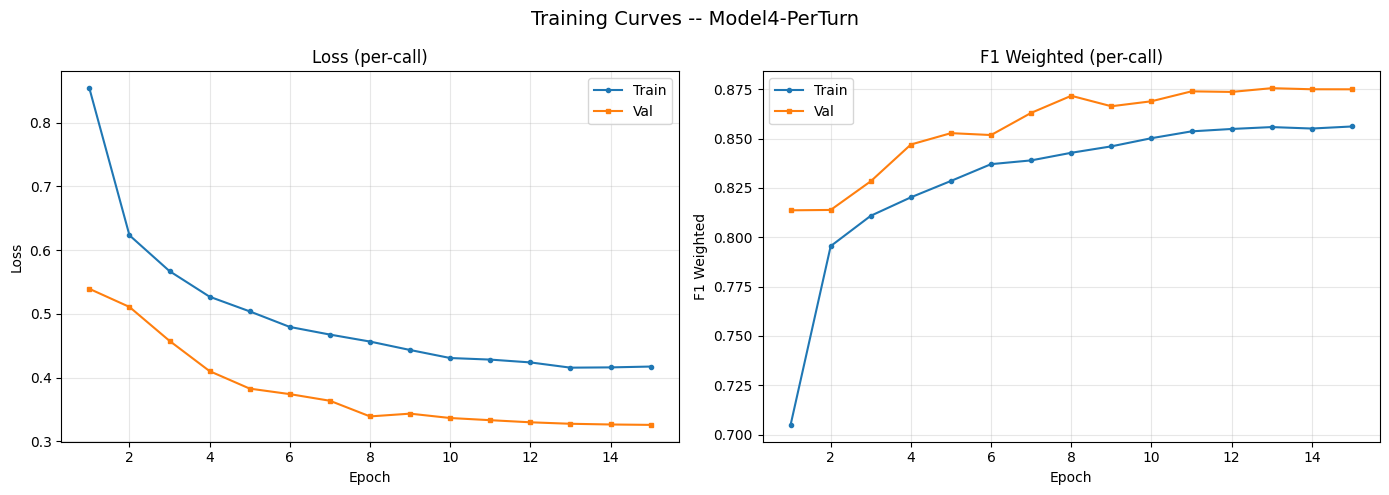

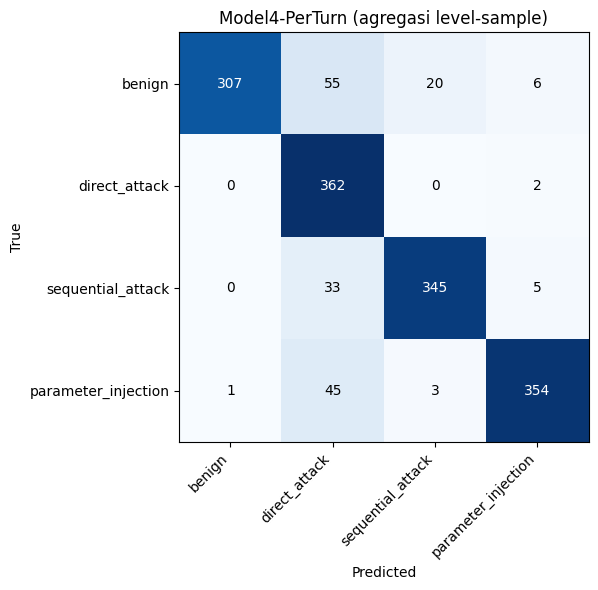

In [8]:
def load_best(model, name):
    ckpt = os.path.join(CHECKPOINT_DIR, f'{name}_best.pt')
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    return model.to(DEVICE)

print('\n' + '='*60)
print('EVALUASI Model4-PerTurn (agregasi level-sample)')
print('='*60)
model4 = load_best(TCSSCPerTurn(freeze_bert=True), 'model4_perturn')
res    = evaluate_final_aggregated(model4, test_loader, DEVICE)
asr    = compute_asr_aggregated(res['preds'], res['labels'])
fpr    = compute_benign_fpr_aggregated(res['preds'], res['labels'])

acc = res['accuracy'] * 100
f1  = res['report']['weighted avg']['f1-score'] * 100
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Weighted':>12} {'ASR (%)':>10} {'Benign FPR (%)':>15}")
print('-' * 60)
print(f"{'Model4-PerTurn':<25} {acc:>9.2f}% {f1:>11.2f}% {asr:>9.2f}% {fpr:>14.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves -- Model4-PerTurn', fontsize=14)
epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(epochs, history['val_loss'],   label='Val',   marker='s', ms=3)
axes[0].set_title('Loss (per-call)'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs, history['train_f1'], label='Train', marker='o', ms=3)
axes[1].plot(epochs, history['val_f1'],   label='Val',   marker='s', ms=3)
axes[1].set_title('F1 Weighted (per-call)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 Weighted')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model4_perturn_training_curves.png'), dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
labels_names = list(LABEL2ID.keys())
cm = res['cm']
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Model4-PerTurn (agregasi level-sample)')
ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(labels_names, rotation=45, ha='right')
ax.set_yticklabels(labels_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model4_perturn_confusion_matrix.png'), dpi=150)
plt.show()


## 9. ASR & Benign FPR vs Baseline


ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN
Baseline (tanpa detektor) : 58.6%
Model4-PerTurn            : 0.09%  (reduksi 58.5pp)


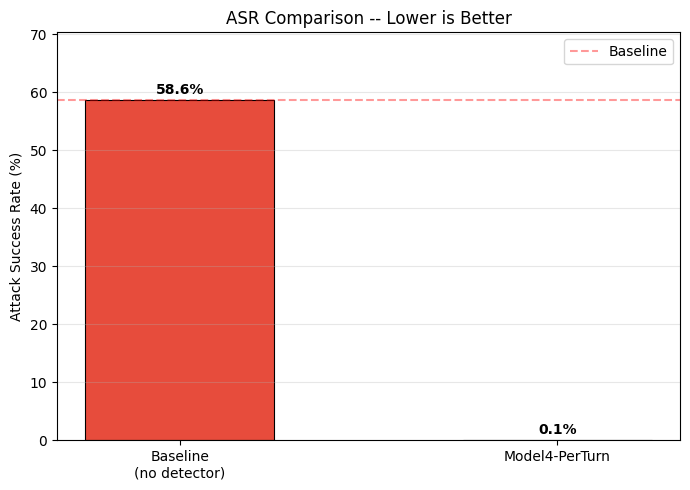


Hasil disimpan di /kaggle/working/outputs/


In [9]:
BASELINE_ASR = 58.6  # ASR STAC baseline (no detector)

print('\n' + '='*60)
print('ATTACK SUCCESS RATE (ASR) -- PERBANDINGAN')
print('='*60)
print(f'Baseline (tanpa detektor) : {BASELINE_ASR:.1f}%')
print(f'Model4-PerTurn            : {asr:.2f}%  (reduksi {BASELINE_ASR - asr:.1f}pp)')

fig, ax = plt.subplots(figsize=(7, 5))
models  = ['Baseline\n(no detector)', 'Model4-PerTurn']
asrs    = [BASELINE_ASR, asr]
colors  = ['#e74c3c', '#9b59b6']
bars    = ax.bar(models, asrs, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, asrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Attack Success Rate (%)')
ax.set_title('ASR Comparison -- Lower is Better')
ax.set_ylim(0, max(asrs) * 1.2)
ax.axhline(BASELINE_ASR, color='red', linestyle='--', alpha=0.4, label='Baseline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model4_perturn_asr_comparison.png'), dpi=150)
plt.show()

summary = {
    'Model4-PerTurn': {
        'accuracy': float(res['accuracy']),
        'f1_weighted': float(res['report']['weighted avg']['f1-score']),
        'asr': float(asr),
        'benign_fpr': float(fpr),
    },
}
with open(os.path.join(OUTPUT_DIR, 'model4_perturn_results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print('\nHasil disimpan di /kaggle/working/outputs/')
